In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
data = pd.read_csv('A_Z_Handwritten_Data.csv')

class AZDataset(Dataset):
    def __init__(self, df):
        self.labels = df.iloc[:, 0].values
        self.images = df.iloc[:, 1:].values.reshape(-1, 28, 28).astype(np.float32) / 255.0

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]).unsqueeze(0), torch.tensor(self.labels[idx], dtype=torch.long)

full_ds = AZDataset(data)
train_ds, test_ds = random_split(full_ds, [0.8, 0.2])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

In [34]:
class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 26))
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LinearNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_losses, test_losses = [], []
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            test_loss += criterion(model(X), y).item()
    test_losses.append(test_loss / len(test_loader))
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

Epoch 1/5 | Train Loss: 0.3583 | Test Loss: 0.1719
Epoch 2/5 | Train Loss: 0.1341 | Test Loss: 0.1174
Epoch 3/5 | Train Loss: 0.0969 | Test Loss: 0.0975
Epoch 4/5 | Train Loss: 0.0770 | Test Loss: 0.0837
Epoch 5/5 | Train Loss: 0.0634 | Test Loss: 0.0737


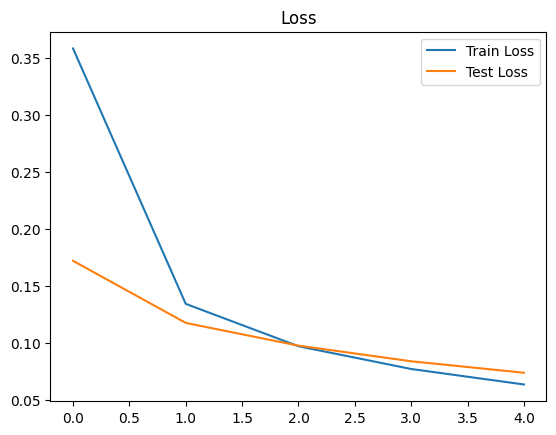

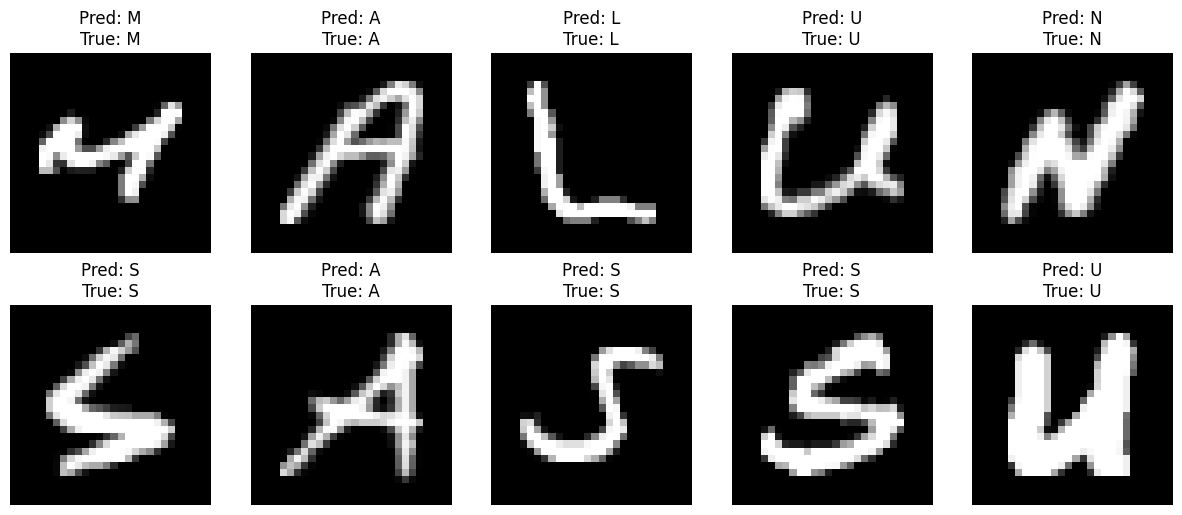

In [37]:
plt.plot(train_losses, label='Train Loss'); plt.plot(test_losses, label='Test Loss'); plt.legend(); plt.title("Loss"); plt.show()

model.eval()
images, labels = next(iter(test_loader))
indices = torch.randperm(len(images))[:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = images[idx].unsqueeze(0).to(device)
    pred = model(img).argmax(dim=1).item()
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(f"Pred: {chr(pred+65)}\nTrue: {chr(labels[idx]+65)}")
    ax.axis('off')
plt.show()